<a href="https://colab.research.google.com/github/bhavika-g/UNet/blob/main/3D_U_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Installing relevant libraries and downloading data
!pip install biapy
!pip install tifffile
!git clone https://github.com/BiaPyX/BiaPy.git
!wget "https://documents.epfl.ch/groups/c/cv/cvlab-unit/www/data/%20ElectronMicroscopy_Hippocampus/training.tif"
!wget "https://documents.epfl.ch/groups/c/cv/cvlab-unit/www/data/%20ElectronMicroscopy_Hippocampus/training_groundtruth.tif"
!wget "https://documents.epfl.ch/groups/c/cv/cvlab-unit/www/data/%20ElectronMicroscopy_Hippocampus/testing.tif"
!wget "https://documents.epfl.ch/groups/c/cv/cvlab-unit/www/data/%20ElectronMicroscopy_Hippocampus/testing_groundtruth.tif"
!pip install timm
!pip install torchmetrics
!pip install pytorch_msssim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.7/362.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4

In [ ]:
#importing libraries

from torch.optim import Adam, SGD
from google.colab import drive
import os
from PIL import Image
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import biapy as biapy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [ ]:

class conv_b(nn.Module):

    " double convolution class with batch normalization and ReLU activation "

    def __init__(self, in_channels, out_channels):
        super(conv_b, self).__init__()
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm3d(out_channels)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(out_channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        return x

class encoder(nn.Module):

    " encoder class ; consists of the convolution block followed by a max pooling layer "

    def __init__(self, in_channels, out_channels):
        super(encoder, self).__init__()
        self.conv = conv_b(in_channels, out_channels)
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        x_pooled = self.pool(x)
        return x, x_pooled

class decoder(nn.Module):

    " decoder class; upsamling and bridging "

    def __init__(self, in_channels, out_channels):
        super(decoder, self).__init__()
        self.upconv = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = conv_b(in_channels, out_channels)

    def forward(self, x, x2):
        x = self.upconv(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv(x)
        return x

class unet_3D(nn.Module):

    " main 3D U-Net class "

    def __init__(self):
        super(unet_3D, self).__init__()
        self.e1 = encoder(1, 64)
        self.e2 = encoder(64, 128)
        self.e3 = encoder(128, 256)
        self.e4 = encoder(256, 512)
        self.bridge = conv_b(512, 1024)
        self.d1 = decoder(1024, 512)
        self.d2 = decoder(512, 256)
        self.d3 = decoder(256, 128)
        self.d4 = decoder(128, 64)
        self.final_conv = nn.Conv3d(64, 1, kernel_size=1)

    def forward(self, x):
        s1, p1 = self.e1(x)  #s1 = [64, 128, 128], #p1 = [64, 64, 64]
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)
        s4, p4 = self.e4(p3)
        b = self.bridge(p4)
        de1 = self.d1(b, s4)
        de2 = self.d2(de1, s3)
        de3 = self.d3(de2, s2)
        de4 = self.d4(de3, s1)
        outputs = self.final_conv(de4)
        return outputs


def compute_iou(pred, target, num_classes=2):

    " function to compute intersection over union "

    ious = []
    for cls in range(0, num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append((intersection / union).item())

    return torch.tensor(ious).nanmean().item()

In [ ]:
class data_cur(Dataset):

    " class to prepare data to load into DataLoader "

    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

In [ ]:
#Loading Data

training_ = '/content/training.tif'
training_gt = '/content/training_groundtruth.tif'
testing = '/content/testing.tif'
testing_gt = '/content/testing_groundtruth.tif'

In [ ]:
#converting data to tiff, expanding dimensions and dividing by 255 for normalisation

train_arr = np.expand_dims(tiff.imread(training_), axis = -1)/255
train_gt_arr = np.expand_dims(tiff.imread(training_gt), axis = -1)/255
test_arr = np.expand_dims(tiff.imread(testing), axis = -1)/255
test_gt_arr = np.expand_dims(tiff.imread(testing_gt), axis = -1)/255

#coverting data to float32 to save space

train_arr_nor = train_arr.astype(np.float32)
train_gt_arr_nor = train_gt_arr.astype(np.float32)
test_arr_nor = test_arr.astype(np.float32)
test_gt_arr_nor = test_gt_arr.astype(np.float32)

#checking data shape to input into function for making patches

print(train_arr_nor.shape)
print(train_gt_arr_nor.shape)
print(test_arr_nor.shape)
print(test_gt_arr_nor.shape)


(165, 768, 1024, 1)
(165, 768, 1024, 1)
(165, 768, 1024, 1)
(165, 768, 1024, 1)


In [ ]:
from BiaPy.biapy.data.data_3D_manipulation import crop_3D_data_with_overlap

In [ ]:
#making patches of training data of size (390, 80, 80, 80, 1)

X_train, Y_train, _ = crop_3D_data_with_overlap(train_arr_nor, (80, 80, 80, 1), data_mask=train_gt_arr_nor, overlap=(0,0,0), load_data=True)

### 3D-OV-CROP ###
Cropping (165, 768, 1024, 1) images into (80, 80, 80, 1) with overlapping . . .
Minimum overlap selected: (0, 0, 0)
Padding: (0, 0, 0)
Real overlapping (%): (0.4625, 0.0375, 0.0125)
Real overlapping (pixels): (37.0, 3.0, 1.0)
(3, 13, 10) patches per (z,y,x) axis
**** New data shape is: (390, 80, 80, 80, 1)
### END 3D-OV-CROP ###


In [ ]:
#making patches of testing data of size (390, 80, 80, 80, 1)

x_test, y_test, _ =  crop_3D_data_with_overlap(test_arr_nor, (80, 80, 80, 1), data_mask=test_gt_arr_nor, overlap=(0,0,0), load_data=True)

### 3D-OV-CROP ###
Cropping (165, 768, 1024, 1) images into (80, 80, 80, 1) with overlapping . . .
Minimum overlap selected: (0, 0, 0)
Padding: (0, 0, 0)
Real overlapping (%): (0.4625, 0.0375, 0.0125)
Real overlapping (pixels): (37.0, 3.0, 1.0)
(3, 13, 10) patches per (z,y,x) axis
**** New data shape is: (390, 80, 80, 80, 1)
### END 3D-OV-CROP ###


In [ ]:
X_train.shape #checking shape

(390, 80, 80, 80, 1)

In [ ]:
X_train = np.transpose(X_train, (0, 4, 1, 2, 3)) #correcting order of dimensions to input into model [N, channels, z, w, h]
Y_train = np.transpose(Y_train, (0, 4, 1, 2, 3))
x_test = np.transpose(x_test, (0, 4, 1, 2, 3))
y_test = np.transpose(y_test, (0, 4, 1, 2, 3))

In [ ]:
train_dataset_0 = data_cur(X_train, Y_train) #preparing for DataLoader
test_dataset = data_cur(x_test, y_test)

train_size = int(0.8 * len(train_dataset_0)) #splitting val set
val_size = len(train_dataset_0) - train_size

train_dataset, val_dataset = random_split(train_dataset_0, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=6, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=6, shuffle=False)

In [ ]:
if torch.cuda.is_available():
    print("GPU is available and will be used.")
else:
    print("GPU is not available, using CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

GPU is available and will be used.


In [ ]:
#Training

model = unet_3D().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = SGD(model.parameters(), lr=2e-2)

train_loss_arr = []
val_loss_arr = []

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

      images = images.to(device)
      labels = labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_loss_arr.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)

            val_outputs = model(val_images)
            loss = criterion(val_outputs, val_labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_loss_arr.append(avg_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {running_loss/len(train_loader):.4f}, Val Loss: {avg_val_loss:.4f}')


Epoch [1/10], Training Loss: 0.3066, Val Loss: 0.2183
Epoch [2/10], Training Loss: 0.1720, Val Loss: 0.1283
Epoch [3/10], Training Loss: 0.1415, Val Loss: 0.1213
Epoch [4/10], Training Loss: 0.1240, Val Loss: 0.1244
Epoch [5/10], Training Loss: 0.1150, Val Loss: 0.1397
Epoch [6/10], Training Loss: 0.1014, Val Loss: 0.0706
Epoch [7/10], Training Loss: 0.0928, Val Loss: 0.0603
Epoch [8/10], Training Loss: 0.0879, Val Loss: 0.1186
Epoch [9/10], Training Loss: 0.0821, Val Loss: 0.0594
Epoch [10/10], Training Loss: 0.0741, Val Loss: 0.0490


In [ ]:
#testing

model.eval()
total_accuracy = 0
total_iou = 0
num_batches = len(test_loader)
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        accuracy = (preds == masks).float().mean()
        iou = compute_iou(preds, masks)

        total_accuracy += accuracy.item()
        total_iou += iou



In [ ]:
avg_accuracy = total_accuracy / num_batches
avg_iou = total_iou / num_batches

print(f"Average Accuracy: {avg_accuracy:.4f}")
print(f"Average IoU: {avg_iou:.4f}")

Average Accuracy: 0.9475
Average IoU: 0.5045


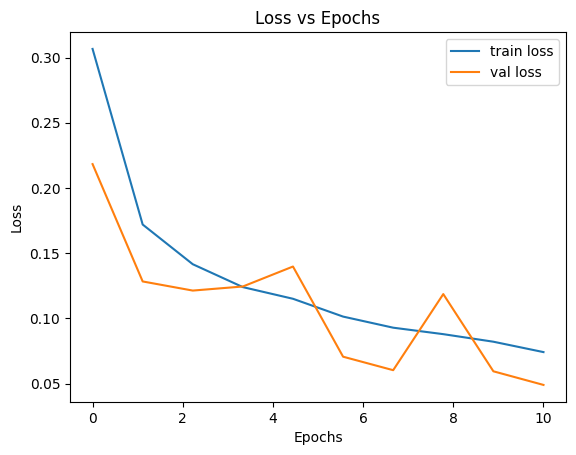

In [ ]:
ep = np.linspace(0, 10, 10)
plt.plot(ep, train_loss_arr, label = 'train loss')
plt.plot(ep, val_loss_arr, label = 'val loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()